# Score Distribution Analysis: Gemma vs Llama

This notebook analyzes and compares the score distributions from evaluation results of two language models on the TriviaQA dataset.

**Models Analyzed:**
- Google Gemma-3-12b-it
- Meta Llama-3.1-8B-Instruct

**Purpose:** Visualize and compare the distribution of evaluation scores to understand model performance patterns.

**Dataset:** JSONL files containing evaluation results with scores ranging from 0.0 to 1.0

## Setup and Imports

Import required libraries for data processing and visualization.

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoConfig

model_id = "meta-llama/Llama-3.2-3B-Instruct"

# Load model on 'meta' device to avoid OOM and downloading huge files
# This creates the skeleton with correct shapes but no actual data
config = AutoConfig.from_pretrained(model_id)
with torch.device("meta"):
    model = AutoModelForCausalLM.from_config(config)

print(f"=== Parameter Shapes for {model_id} ===\n")

total_params = 0
for name, param in model.named_parameters():
    # Skip the "model." prefix for cleaner output if desired, or keep full paths
    print(f"{name}: {tuple(param.shape)}")
    
    # Calculate total parameters to verify
    param_count = 1
    for dim in param.shape:
        param_count *= dim
    total_params += param_count

print(f"\nTotal Parameters: {total_params:,}")

/root/my_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Parameter Shapes for meta-llama/Llama-3.2-3B-Instruct ===

model.embed_tokens.weight: (128256, 3072)
model.layers.0.self_attn.q_proj.weight: (3072, 3072)
model.layers.0.self_attn.k_proj.weight: (1024, 3072)
model.layers.0.self_attn.v_proj.weight: (1024, 3072)
model.layers.0.self_attn.o_proj.weight: (3072, 3072)
model.layers.0.mlp.gate_proj.weight: (8192, 3072)
model.layers.0.mlp.up_proj.weight: (8192, 3072)
model.layers.0.mlp.down_proj.weight: (3072, 8192)
model.layers.0.input_layernorm.weight: (3072,)
model.layers.0.post_attention_layernorm.weight: (3072,)
model.layers.1.self_attn.q_proj.weight: (3072, 3072)
model.layers.1.self_attn.k_proj.weight: (1024, 3072)
model.layers.1.self_attn.v_proj.weight: (1024, 3072)
model.layers.1.self_attn.o_proj.weight: (3072, 3072)
model.layers.1.mlp.gate_proj.weight: (8192, 3072)
model.layers.1.mlp.up_proj.weight: (8192, 3072)
model.layers.1.mlp.down_proj.weight: (3072, 8192)
model.layers.1.input_layernorm.weight: (3072,)
model.layers.1.post_atten

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple
from collections import Counter

# Configure matplotlib for better-looking plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## Data Loading Function

Function to load and extract scores from the JSONL file.

In [2]:
def load_scores_from_jsonl(file_path: str) -> List[float]:
    """
    Load evaluation scores from a JSONL file.
    
    Args:
        file_path: Path to the JSONL file containing evaluation results
    
    Returns:
        List of score values extracted from the 'base_eval.score' field
    
    Raises:
        FileNotFoundError: If the specified file doesn't exist
        json.JSONDecodeError: If the file contains invalid JSON
        KeyError: If expected fields are missing from the data
    """
    file_path = Path(file_path)
    
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")
    
    scores = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            
            try:
                data = json.loads(line)
                score = data['base_eval']['score']
                scores.append(float(score))
            except (json.JSONDecodeError, KeyError) as e:
                print(f"Warning: Skipping line {line_num} due to error: {e}")
                continue
    
    return scores

## Histogram Plotting Function

Main function to create a histogram visualization of score distribution.

In [3]:
def plot_score_histogram(
    scores: List[float],
    bins: int = 20,
    title: str = "Score Distribution for Google Gemma-3-12b-it",
    show_stats: bool = True,
    save_path: str = None
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot a histogram of evaluation scores.
    
    Args:
        scores: List of score values to plot
        bins: Number of bins for the histogram (default: 20)
        title: Title for the plot
        show_stats: Whether to display statistics on the plot (default: True)
        save_path: Optional path to save the figure (default: None)
    
    Returns:
        Tuple of (figure, axes) objects for further customization
    
    Raises:
        ValueError: If scores list is empty
    """
    if not scores:
        raise ValueError("Scores list is empty. Cannot create histogram.")
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Calculate histogram data
    counts, bin_edges, patches = ax.hist(
        scores,
        bins=bins,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.75,
        color='steelblue'
    )
    
    # Set labels and title
    ax.set_xlabel('Score Value', fontweight='bold')
    ax.set_ylabel('Number of Questions', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=20)
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Calculate and display statistics if requested
    if show_stats:
        mean_score = np.mean(scores)
        median_score = np.median(scores)
        std_score = np.std(scores)
        total_questions = len(scores)
        
        # Create statistics text box
        stats_text = (
            f'Total Questions: {total_questions}\n'
            f'Mean Score: {mean_score:.3f}\n'
            f'Median Score: {median_score:.3f}\n'
            f'Std Dev: {std_score:.3f}\n'
            f'Min: {min(scores):.3f}\n'
            f'Max: {max(scores):.3f}'
        )
        
        # Add text box with statistics
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(
            0.98, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props,
            family='monospace'
        )
        
        # Add vertical lines for mean and median
        ax.axvline(
            mean_score, color='red', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Mean: {mean_score:.3f}'
        )
        ax.axvline(
            median_score, color='green', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Median: {median_score:.3f}'
        )
        
        ax.legend(loc='upper left', framealpha=0.9)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, ax

## Detailed Score Distribution Analysis

Additional function to show the exact count for each unique score value.

In [4]:
def analyze_score_distribution(scores: List[float]) -> Dict[float, int]:
    """
    Analyze the distribution of scores by counting occurrences of each unique value.
    
    Args:
        scores: List of score values
    
    Returns:
        Dictionary mapping each unique score to its count
    """
    score_counts = Counter(scores)
    
    # Sort by score value
    sorted_scores = dict(sorted(score_counts.items()))
    
    print("Score Distribution:")
    print("=" * 40)
    print(f"{'Score':<10} {'Count':<10} {'Percentage':<10}")
    print("-" * 40)
    
    total = len(scores)
    for score, count in sorted_scores.items():
        percentage = (count / total) * 100
        print(f"{score:<10.3f} {count:<10} {percentage:<10.2f}%")
    
    print("=" * 40)
    print(f"Total: {total} questions\n")
    
    return sorted_scores

## Gemma-3-12b-it Analysis

Load and analyze the evaluation results for the Google Gemma model.

In [6]:
# Load Gemma model scores
gemma_file_path = "../results/gemma-12b/google_gemma-3-12b-it_scores-final.jsonl"

try:
    gemma_scores = load_scores_from_jsonl(gemma_file_path)
    print(f"✓ Successfully loaded {len(gemma_scores)} scores from Gemma model")
except Exception as e:
    print(f"✗ Error loading Gemma data: {e}")
    raise

✓ Successfully loaded 76496 scores from Gemma model


In [7]:
# Analyze Gemma score distribution
print("\n=== Gemma-3-12b-it Score Distribution ===")
gemma_distribution = analyze_score_distribution(gemma_scores)


=== Gemma-3-12b-it Score Distribution ===
Score Distribution:
Score      Count      Percentage
----------------------------------------
0.000      29336      38.35     %
0.100      305        0.40      %
0.200      310        0.41      %
0.300      271        0.35      %
0.400      253        0.33      %
0.500      275        0.36      %
0.600      230        0.30      %
0.700      261        0.34      %
0.800      289        0.38      %
0.900      263        0.34      %
1.000      44703      58.44     %
Total: 76496 questions



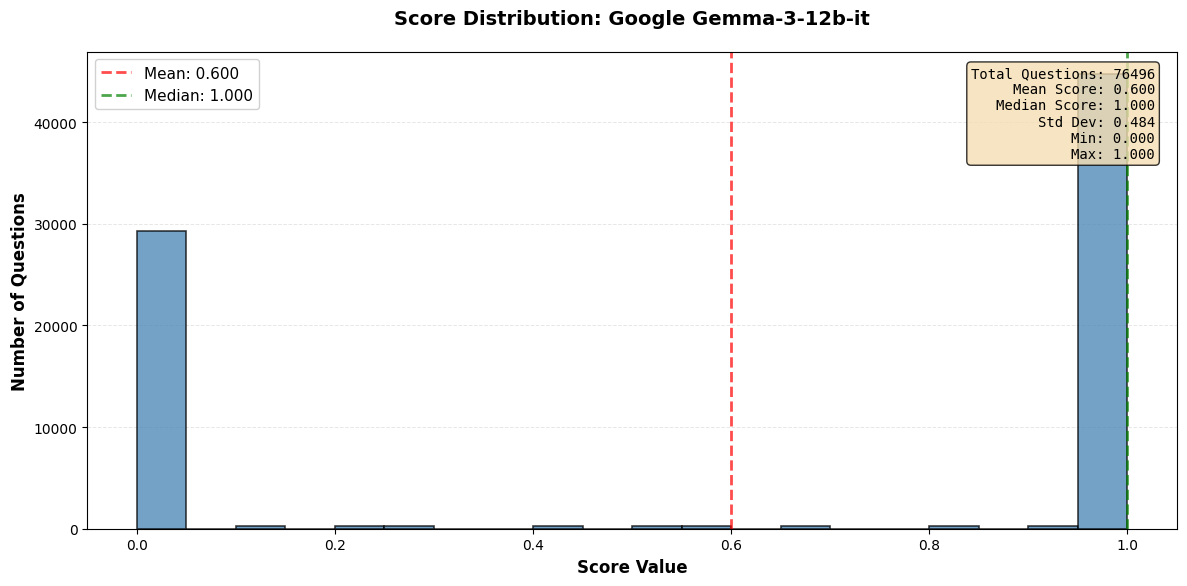

In [8]:
# Create histogram for Gemma
fig_gemma, ax_gemma = plot_score_histogram(
    scores=gemma_scores,
    bins=20,
    title="Score Distribution: Google Gemma-3-12b-it",
    show_stats=True,
    save_path=None  # Set to 'gemma_histogram.png' to save
)

plt.show()

## Llama-3.1-8B-Instruct Analysis

Load and analyze the evaluation results for the Meta Llama model.

In [11]:
# Load Llama model scores
llama_8b_file_path = "../results/llama-8b/meta-llama_Llama-3.1-8B-Instruct_scores-final.jsonl"

try:
    llama_8b_scores = load_scores_from_jsonl(llama_8b_file_path)
    print(f"✓ Successfully loaded {len(llama_8b_scores)} scores from Llama model")
except Exception as e:
    print(f"✗ Error loading Llama data: {e}")
    raise

✓ Successfully loaded 76523 scores from Llama model


In [12]:
# Analyze Llama score distribution
print("\n=== Llama-3.1-8B-Instruct Score Distribution ===")
llama_distribution = analyze_score_distribution(llama_8b_scores)


=== Llama-3.1-8B-Instruct Score Distribution ===
Score Distribution:
Score      Count      Percentage
----------------------------------------
0.000      61586      80.48     %
0.100      5150       6.73      %
0.200      3273       4.28      %
0.300      1984       2.59      %
0.400      1247       1.63      %
0.500      785        1.03      %
0.600      565        0.74      %
0.700      451        0.59      %
0.800      346        0.45      %
0.900      306        0.40      %
1.000      830        1.08      %
Total: 76523 questions



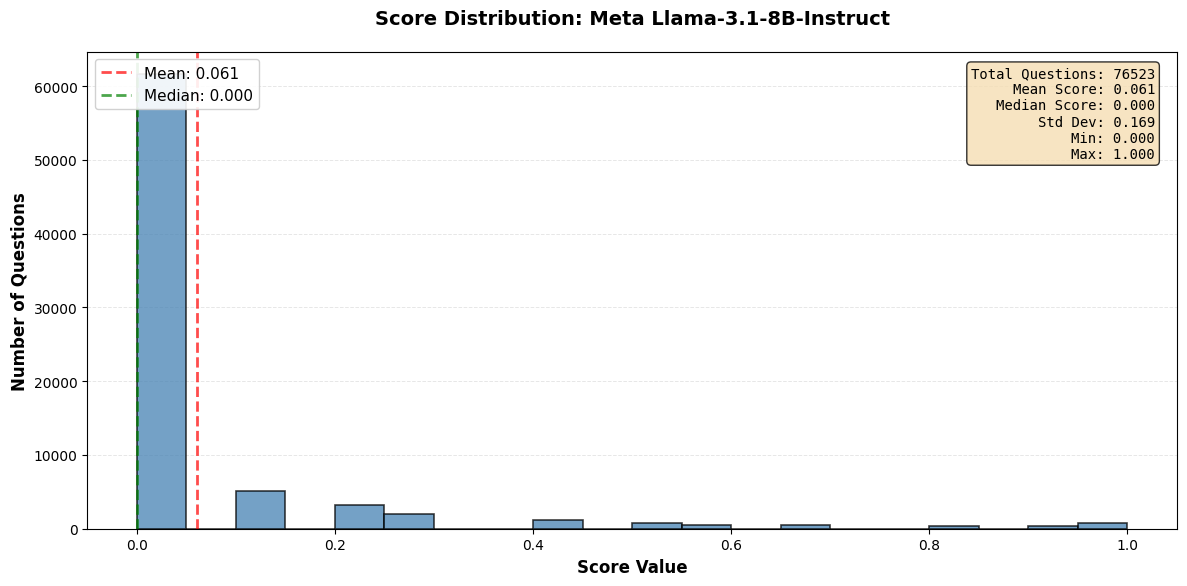

In [13]:
# Create histogram for Llama
fig_llama, ax_llama = plot_score_histogram(
    scores=llama_8b_scores,
    bins=20,
    title="Score Distribution: Meta Llama-3.1-8B-Instruct",
    show_stats=True,
    save_path=None  # Set to 'llama_histogram.png' to save
)

plt.show()

✓ Successfully loaded 76523 scores from Llama model

=== Llama-3.1-3B-Instruct Score Distribution ===
Score Distribution:
Score      Count      Percentage
----------------------------------------
0.000      32799      42.86     %
0.100      1300       1.70      %
0.200      1176       1.54      %
0.300      1010       1.32      %
0.400      930        1.22      %
0.500      868        1.13      %
0.600      867        1.13      %
0.700      1041       1.36      %
0.800      1085       1.42      %
0.900      1115       1.46      %
1.000      34332      44.86     %
Total: 76523 questions



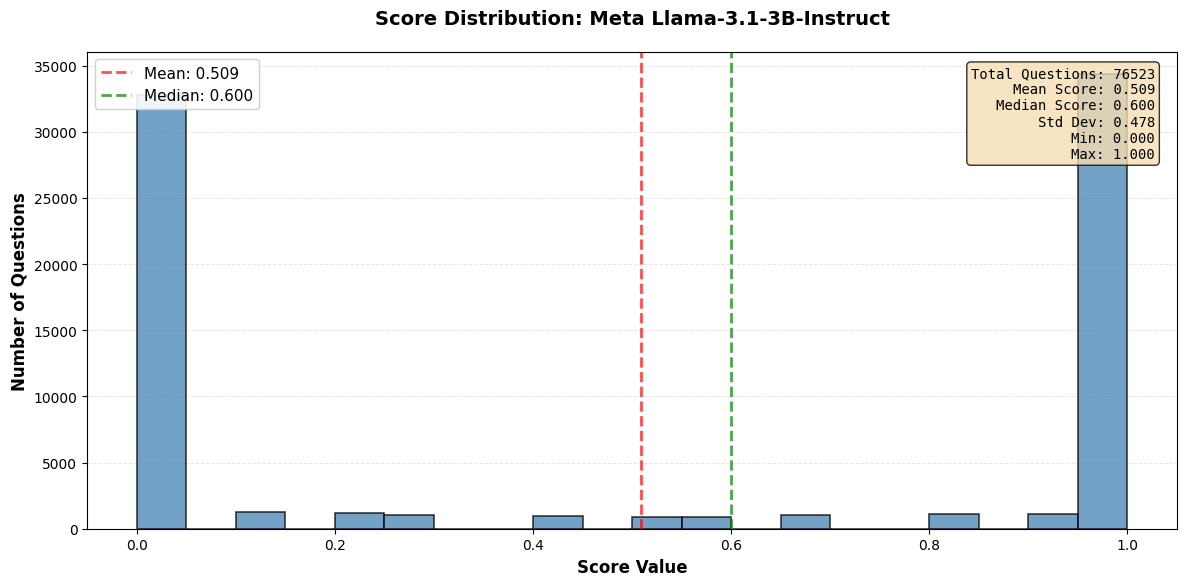

In [15]:
# Load Llama model scores
llama_3b_file_path = "../results/llama-3b/meta-llama_Llama-3.2-3B-Instruct_scores-final.jsonl"

try:
    llama_3b_scores = load_scores_from_jsonl(llama_3b_file_path)
    print(f"✓ Successfully loaded {len(llama_3b_scores)} scores from Llama model")
except Exception as e:
    print(f"✗ Error loading Llama data: {e}")
    raise

# Analyze Llama score distribution
print("\n=== Llama-3.1-3B-Instruct Score Distribution ===")
llama_distribution = analyze_score_distribution(llama_3b_scores)

# Create histogram for Llama
fig_llama, ax_llama = plot_score_histogram(
    scores=llama_3b_scores,
    bins=20,
    title="Score Distribution: Meta Llama-3.1-3B-Instruct",
    show_stats=True,
    save_path=None  # Set to 'llama_histogram.png' to save
)

plt.show()

In [ ]:
stop

## Side-by-Side Comparison

Compare both models using a side-by-side visualization.

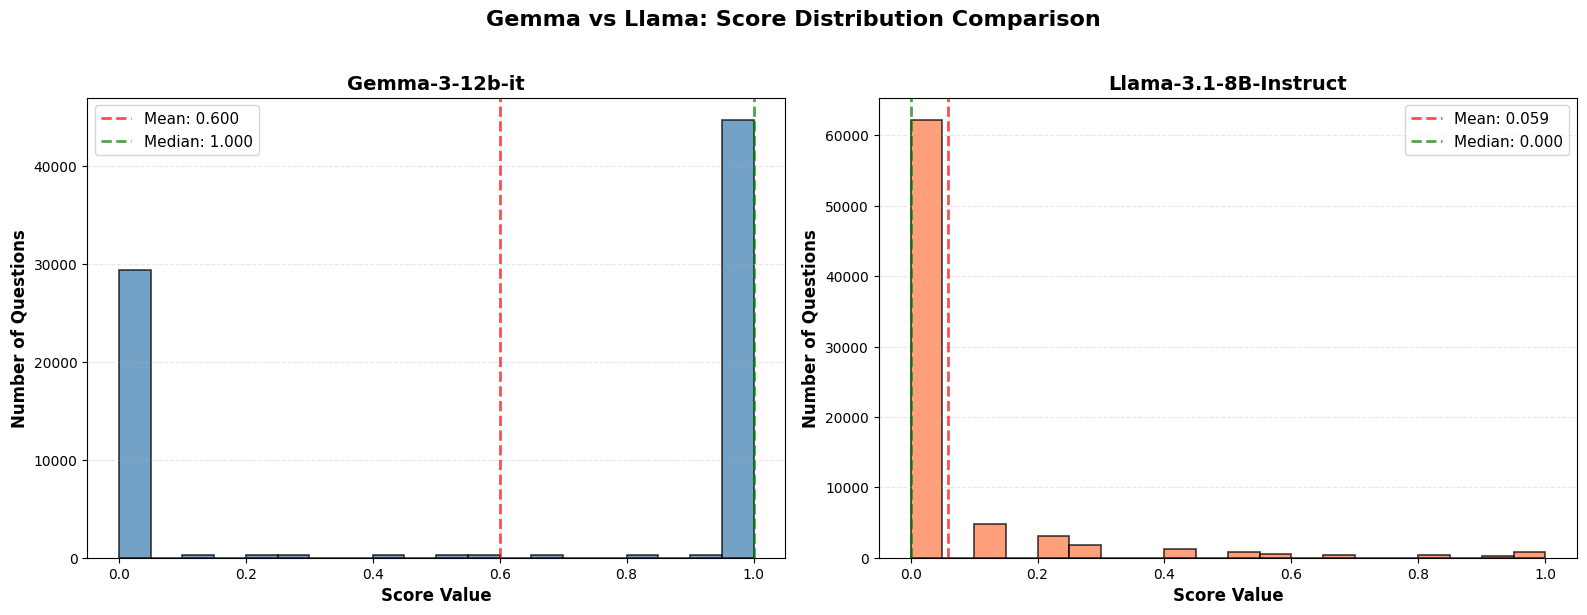

In [ ]:
# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gemma histogram (left)
axes[0].hist(
    gemma_scores,
    bins=20,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.75,
    color='steelblue'
)
gemma_mean = np.mean(gemma_scores)
gemma_median = np.median(gemma_scores)
axes[0].axvline(gemma_mean, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {gemma_mean:.3f}')
axes[0].axvline(gemma_median, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Median: {gemma_median:.3f}')
axes[0].set_xlabel('Score Value', fontweight='bold')
axes[0].set_ylabel('Number of Questions', fontweight='bold')
axes[0].set_title('Gemma-3-12b-it', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend()

# Llama histogram (right)
axes[1].hist(
    llama_scores,
    bins=20,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.75,
    color='coral'
)
llama_mean = np.mean(llama_scores)
llama_median = np.median(llama_scores)
axes[1].axvline(llama_mean, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {llama_mean:.3f}')
axes[1].axvline(llama_median, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Median: {llama_median:.3f}')
axes[1].set_xlabel('Score Value', fontweight='bold')
axes[1].set_ylabel('Number of Questions', fontweight='bold')
axes[1].set_title('Llama-3.1-8B-Instruct', fontweight='bold', fontsize=14)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].legend()

plt.suptitle('Gemma vs Llama: Score Distribution Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Print comparison statistics
print("\n" + "=" * 90)
print("Model Performance Comparison")
print("=" * 90)
print(f"{'Model':<30} {'Count':<10} {'Mean':<10} {'Median':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10}")
print("-" * 90)

# Gemma stats
print(f"{'Gemma-3-12b-it':<30} {len(gemma_scores):<10} {np.mean(gemma_scores):<10.3f} "
      f"{np.median(gemma_scores):<10.3f} {np.std(gemma_scores):<10.3f} "
      f"{np.min(gemma_scores):<10.3f} {np.max(gemma_scores):<10.3f}")

# Llama stats
print(f"{'Llama-3.1-8B-Instruct':<30} {len(llama_scores):<10} {np.mean(llama_scores):<10.3f} "
      f"{np.median(llama_scores):<10.3f} {np.std(llama_scores):<10.3f} "
      f"{np.min(llama_scores):<10.3f} {np.max(llama_scores):<10.3f}")

print("=" * 90)

# Calculate and display differences
mean_diff = np.mean(llama_scores) - np.mean(gemma_scores)
median_diff = np.median(llama_scores) - np.median(gemma_scores)

print(f"\nPerformance Difference (Llama - Gemma):")
print(f"  Mean difference:   {mean_diff:+.3f}")
print(f"  Median difference: {median_diff:+.3f}")
print("=" * 90 + "\n")


Model Performance Comparison
Model                          Count      Mean       Median     Std Dev    Min        Max       
------------------------------------------------------------------------------------------
Gemma-3-12b-it                 76496      0.600      1.000      0.484      0.000      1.000     
Llama-3.1-8B-Instruct          76496      0.059      0.000      0.168      0.000      1.000     

Performance Difference (Llama - Gemma):
  Mean difference:   -0.541
  Median difference: -1.000



## Overlaid Comparison

View both distributions overlaid on the same plot for direct comparison.

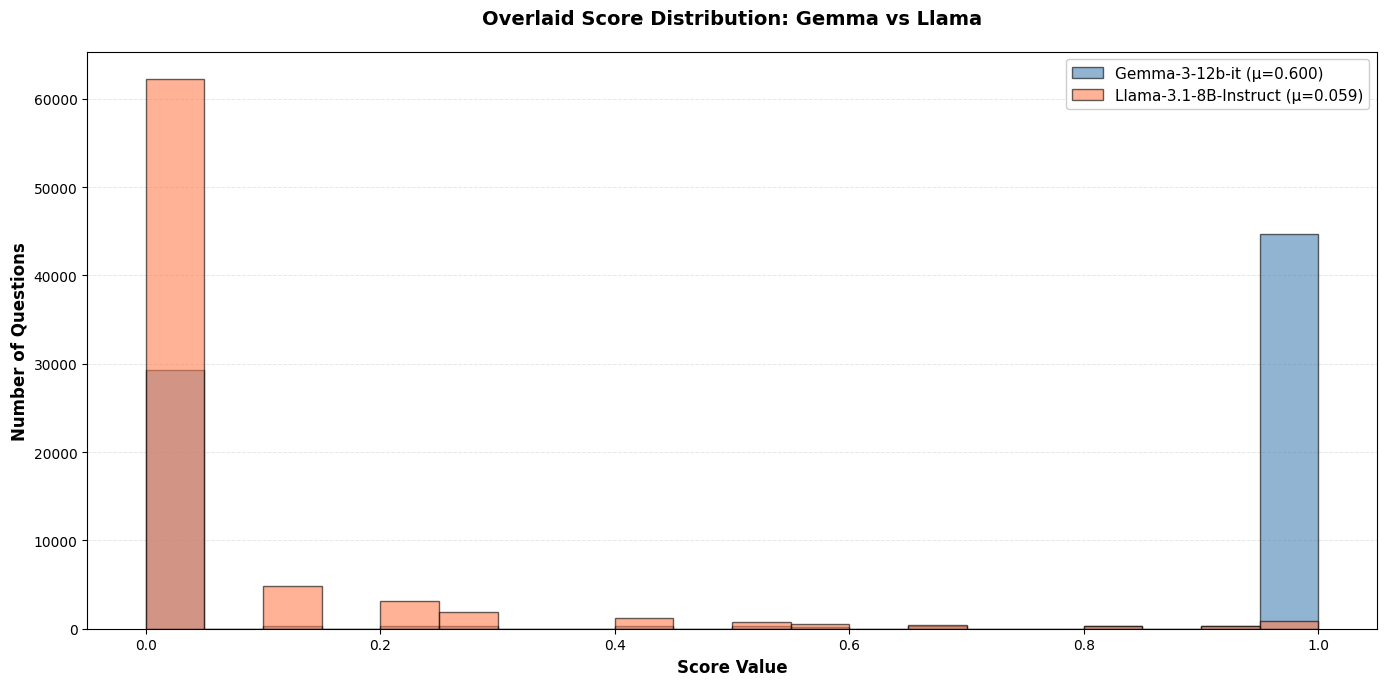

In [ ]:
# Create overlaid histogram
fig, ax = plt.subplots(figsize=(14, 7))

# Plot both distributions
ax.hist(
    gemma_scores,
    bins=20,
    edgecolor='black',
    linewidth=1,
    alpha=0.6,
    color='steelblue',
    label=f'Gemma-3-12b-it (μ={np.mean(gemma_scores):.3f})'
)

ax.hist(
    llama_scores,
    bins=20,
    edgecolor='black',
    linewidth=1,
    alpha=0.6,
    color='coral',
    label=f'Llama-3.1-8B-Instruct (μ={np.mean(llama_scores):.3f})'
)

ax.set_xlabel('Score Value', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Questions', fontweight='bold', fontsize=12)
ax.set_title('Overlaid Score Distribution: Gemma vs Llama', fontweight='bold', fontsize=14, pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(loc='best', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

## Alternative Visualization: Bar Chart by Unique Score

For datasets with discrete score values, a bar chart may be more appropriate than a histogram.

In [ ]:
def plot_score_bar_chart(
    score_distribution: Dict[float, int],
    title: str = "Question Count by Score Value"
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot a bar chart showing the count of questions for each unique score.
    
    Args:
        score_distribution: Dictionary mapping scores to their counts
        title: Title for the plot
    
    Returns:
        Tuple of (figure, axes) objects
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    scores = list(score_distribution.keys())
    counts = list(score_distribution.values())
    
    # Create bar chart
    bars = ax.bar(
        scores, counts,
        width=0.05,
        edgecolor='black',
        linewidth=1.2,
        alpha=0.75,
        color='coral'
    )
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2., height,
                f'{int(height)}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )
    
    # Set labels and title
    ax.set_xlabel('Score Value', fontweight='bold')
    ax.set_ylabel('Number of Questions', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    return fig, ax

In [ ]:
# Optional: Create bar charts for discrete score values
# Uncomment to visualize if your scores have discrete values

# fig_gemma_bar, ax_gemma_bar = plot_score_bar_chart(
#     gemma_distribution,
#     title="Gemma-3-12b-it: Question Count by Score Value"
# )
# plt.show()

# fig_llama_bar, ax_llama_bar = plot_score_bar_chart(
#     llama_distribution,
#     title="Llama-3.1-8B-Instruct: Question Count by Score Value"
# )
# plt.show()

## Summary

This notebook provides comprehensive visualization and comparison of score distributions between Google Gemma-3-12b-it and Meta Llama-3.1-8B-Instruct models.

**Key Features:**

**Individual Model Analysis:**
- Load scores from JSONL format
- Generate histograms with statistical overlays (mean, median, std dev)
- Display detailed score distribution tables
- Calculate comprehensive statistics

**Comparative Analysis:**
- Side-by-side histogram visualization
- Overlaid distribution comparison
- Statistical comparison table
- Performance difference metrics

**Visualization Options:**
- Standard histograms with statistics
- Bar charts for discrete score values
- Customizable bins and styling
- Export capabilities for all plots

**Models Analyzed:**
- Google Gemma-3-12b-it
- Meta Llama-3.1-8B-Instruct

**Usage:**
1. Run all cells sequentially for complete analysis
2. Each model is analyzed individually first
3. Comparison visualizations show differences between models
4. All functions include error handling and documentation